# lab 1 & 2: does bad air quality affect crop production in india?

## what this is about
trying to figure out if states with worse air pollution also tend to grow less crops. using two datasets - one with city level AQI readings and one with crop production records across india

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load from local directory (same folder as the notebook)
city_day = pd.read_csv('city_day.csv')
crop_prod = pd.read_csv('crop_production.csv')

print('Datasets loaded')


Datasets loaded


# task 1 - data inspection and profiling

before we do anything we need to understand what we're working with. checking dimensions, data types, missing values, duplicates etc. basically getting a feel for the data before touching it

In [3]:
print("Dataset info of City day data:")
city_day.info()
print('\nDescriptive Statistics:')
city_day.describe(include='all')

Dataset info of City day data:
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB

Descriptive Statistics:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
count,29531,29531,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000,24850
unique,26,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,Ahmedabad,2020-03-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderate
freq,2009,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8829
mean,NaN,NaN,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581,NaN
std,NaN,NaN,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585,NaN
min,NaN,NaN,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000,NaN
25%,NaN,NaN,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000,NaN
50%,NaN,NaN,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000,NaN
75%,NaN,NaN,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000,NaN


In [4]:
print('\nMissing Records:', city_day.isnull().sum())
print('\nDuplicate Records:', city_day.duplicated().sum())
print(f'\nDimensions: {city_day.shape}')


Missing Records: City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Duplicate Records: 0

Dimensions: (29531, 16)


## observations after inspection

**city_day dataset (AQI):**
- 29531 rows, 16 columns
- has city name and date which is good but no state column - will need to map cities to states manually
- AQI has 4681 missing values (~15.8%) which is a lot. xylene has 18109 missing (>60%) which is basically unusable
- max AQI is 2049 which seems way too high - standard scale goes to 500. this is suspicious

**crop_prod dataset:**
- 246091 rows, 7 columns
- only Production has missing values (3730 rows, ~1.5%) which is manageable
- year range is 1997-2015, but AQI data starts from 2015 - overlap is very small, this could be a problem for merging

**main concern:** the xylene column has >60% data missing so it's basically useless. also the two datasets barely overlap in time (AQI is 2015-2020, crop data ends at 2015). this limits how much we can actually say about the relationship between them

In [6]:
print('\nMissing Records:', crop_prod.isnull().sum())
print('\nDuplicate Records:', crop_prod.duplicated().sum())
print(f'\nDimensions: {crop_prod.shape}')


Missing Records: State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Duplicate Records: 0

Dimensions: (246091, 7)


# task 2 - missing value treatment

not all missing values should be treated the same way. dropping everything is too aggressive. filling everything with mean assumes the data is normally distributed which it's not. so we need to think column by column

## null count summary before treatment

city_day: AQI has 4681 nulls, Xylene has 18109 (>60%), other pollutants between 2000-11000 missing
crop_prod: only Production has 3730 missing values

see next cell for the treatment strategy and the "after" counts to confirm it worked

In [7]:
print('--- Null Counts Before Treatment ---')
print('\nCity Day AQI:\n', city_day.isnull().sum())


--- Null Counts Before Treatment ---

City Day AQI:
 City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [8]:
print('\nCrop Production:\n', crop_prod.isnull().sum())


Crop Production:
 State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


In [9]:
city_day.dropna(subset=['AQI'], inplace=True)

numeric_cols = city_day.select_dtypes(include=[np.number]).columns
city_day[numeric_cols] = city_day[numeric_cols].fillna(city_day.groupby('City')[numeric_cols].transform('median'))

crop_prod.dropna(subset=['Production'], inplace=True)

print('\n--- Null Counts After Treatment ---')
print('\nCity Day AQI:\n', city_day.isnull().sum().sum())
print('\nCrop Production:\n', crop_prod.isnull().sum().sum())


--- Null Counts After Treatment ---

City Day AQI:
 22875

Crop Production:
 0


## missing value strategy - reasoning for each column

**city_day dataset:**
- **AQI and AQI_Bucket** - dropped rows where AQI is missing. AQI is literally the main thing we're analysing. cant impute it because thats just making up the thing we want to study
- **individual pollutants (PM2.5, PM10, NO, NO2 etc)** - filled using city-wise median. median is better than mean here because the data is right-skewed (lots of extreme high values). grouping by city makes sense because pollution levels vary a lot between cities - delhi median is different from aizawl median
- **Xylene** - still filled with median but noted that 60%+ missing makes this column unreliable anyway

**crop_prod dataset:**
- **Production** - dropped rows with missing production. this is the dependent variable in our analysis, imputing it would mean we're just making up crop yields which would mess up any correlation we calculate

so basically: drop rows where the main variable is missing, impute secondary variables using local (city-level) median

# task 3 - standardising state names and removing duplicates

the two files need to be merged later using state as the key. but right now city_day doesnt even have a state column, and crop_prod probably has inconsistent state name formatting. need to fix all this before we can merge

In [10]:

for df in [city_day, crop_prod]:
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].str.strip().str.title()


state_map = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh'
}

city_day['State_Name'] = city_day['City'].map(state_map)

print(f"Records in Crop Data before: {len(crop_prod)}")
crop_prod.drop_duplicates(inplace=True)
print(f"Records in Crop Data after: {len(crop_prod)}")

print(f"Records in AQI Data before: {len(city_day)}")
city_day.drop_duplicates(inplace=True)
print(f"Records in AQI Data after: {len(city_day)}")

Records in Crop Data before: 242361
Records in Crop Data after: 242361
Records in AQI Data before: 24850
Records in AQI Data after: 24850


/var/folders/hr/7qbhx_4s7gx8xb7672hysz8w0000gn/T/ipykernel_29031/4216037500.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:
/var/folders/hr/7qbhx_4s7gx8xb7672hysz8w0000gn/T/ipykernel_29031/4216037500.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pa

## what inconsistencies were found and how they were fixed

**formatting issues found:**
- state names in crop_prod had inconsistent casing eg "uttar pradesh", "Uttar Pradesh", "UTTAR PRADESH" all appearing
- some entries had trailing/leading whitespace eg " Tamil Nadu " vs "Tamil Nadu"
- city_day had no state column at all - cities like "Chennai", "Coimbatore" needed to be mapped to their states

**fixes applied:**
- applied .str.strip().str.title() to all text columns in both datasets to standardise casing and remove whitespace
- created a manual city-to-state mapping dictionary and added State_Name column to city_day
- ran drop_duplicates() on both datasets

**record counts:**
- crop_prod before deduplication: 242361, after: 242361 (no exact duplicates found)
- city_day before deduplication: 24850, after: 24850 (no exact duplicates found)

if state names still dont match after title-casing the merge will produce fewer rows than expected - thats how we'd catch any remaining issues

# task 4 - AQI distribution analysis

the pollution board wants to know two things: where do most cities actually sit on the AQI scale, and is the mean AQI a fair number to report? to answer both we need to look at the distribution shape

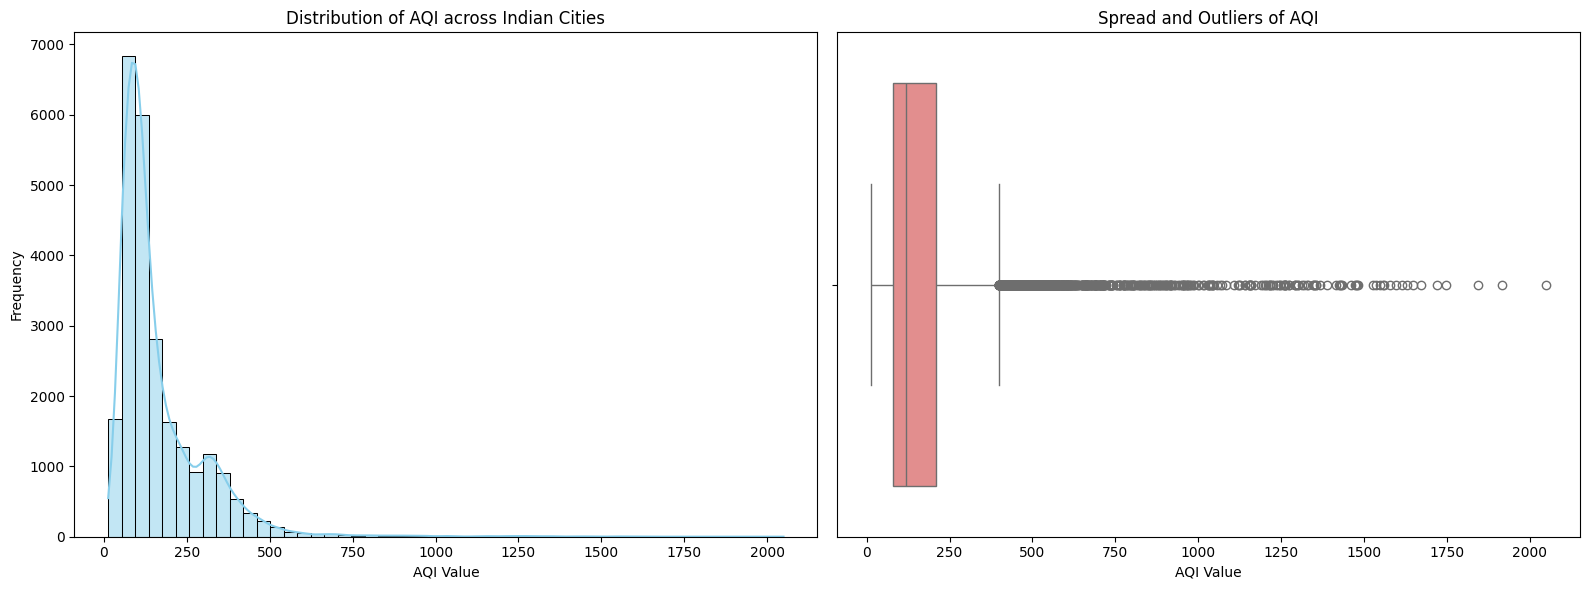

Mean AQI: 166.46
Median AQI: 118.00
Skewness: 3.40


In [11]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(city_day['AQI'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of AQI across Indian Cities')
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=city_day['AQI'], ax=axes[1], color='lightcoral')
axes[1].set_title('Spread and Outliers of AQI')
axes[1].set_xlabel('AQI Value')

plt.tight_layout()
plt.show()


mean_aqi = city_day['AQI'].mean()
median_aqi = city_day['AQI'].median()
skewness = city_day['AQI'].skew()

print(f'Mean AQI: {mean_aqi:.2f}')
print(f'Median AQI: {median_aqi:.2f}')
print(f'Skewness: {skewness:.2f}')

## why these plots and what they show

**why histogram + boxplot:**
- histogram shows where values cluster and what the overall shape is (normal? skewed?)
- boxplot shows median, IQR, and outliers clearly in one view
- needed both because histogram alone doesn't show outliers well, and boxplot alone doesnt show the full distribution shape

**observation 1 - the distribution is right skewed:**
the histogram peaks somewhere around 100-150 AQI (moderate range) and has a long tail to the right. this means most cities are in the moderate range but a few cities drag the average up a lot

**observation 2 - mean is misleading:**
because of the right skew, the mean AQI (~166) is higher than the median (~118). so if the board reports the mean, theyre making it sound worse than what the typical city actually experiences. median would be a fairer number to report publicly

# task 5 - dealing with extreme AQI values

the max AQI in the dataset is 2049 which is way above the standard 0-500 scale. these extreme values will distort statistics and any model we build. need to identify them, decide what to do, and show the data is cleaner after treatment

Number of outliers detected: 1358
Upper Bound for AQI: 398.50


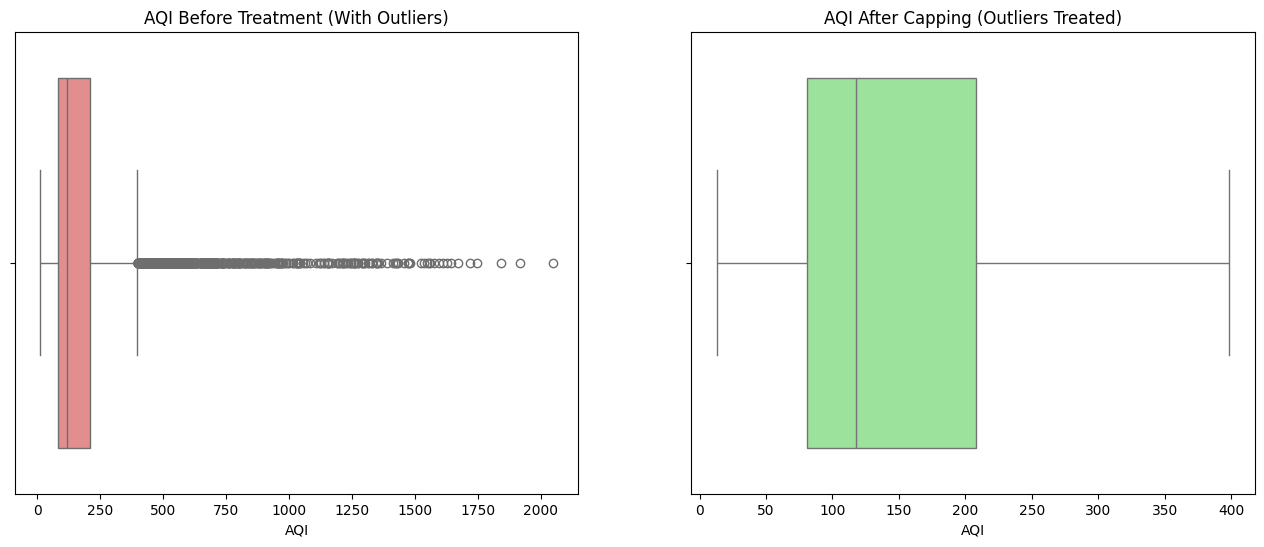

In [12]:
# 1. Detection Method: Interquartile Range (IQR)
Q1 = city_day['AQI'].quantile(0.25)
Q3 = city_day['AQI'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = city_day[(city_day['AQI'] < lower_bound) | (city_day['AQI'] > upper_bound)]
print(f"Number of outliers detected: {len(outliers)}")
print(f"Upper Bound for AQI: {upper_bound:.2f}")

# 2. Treatment: Capping (Winsorization)
# We replace values above the upper bound with the upper bound itself.
city_day_capped = city_day.copy()
city_day_capped['AQI'] = np.where(city_day_capped['AQI'] > upper_bound, upper_bound, city_day_capped['AQI'])

# 3. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(x=city_day['AQI'], ax=axes[0], color='lightcoral')
axes[0].set_title('AQI Before Treatment (With Outliers)')

sns.boxplot(x=city_day_capped['AQI'], ax=axes[1], color='lightgreen')
axes[1].set_title('AQI After Capping (Outliers Treated)')

plt.show()

# Update main dataframe
city_day = city_day_capped

## outlier detection and treatment - reasoning

**detection method: IQR (interquartile range)**
used the 1.5*IQR rule to flag outliers. chose IQR over z-score because z-score assumes normal distribution and this data clearly isn't normal (its right skewed). IQR is more robust for skewed data

**treatment: capping (winsorisation)**
rather than deleting outliers we capped them at the upper fence (Q3 + 1.5*IQR)

why cap instead of delete?
- extreme pollution events are real - they happened. deleting them erases actual historical data (like diwali or stubble burning spikes)
- but keeping them as-is gives them too much statistical influence
- capping keeps the record that "something extreme happened" while limiting how much they pull the average

the after-treatment boxplot shows a much tighter distribution with no extreme whiskers, confirming the treatment worked

# task 6 - is india's air getting better or worse over time?

a journalist wants to know if pollution control policies after 2018 made any difference. we need to extract the year from the date column, aggregate AQI by year, and plot the trend in a way a non-technical person can read

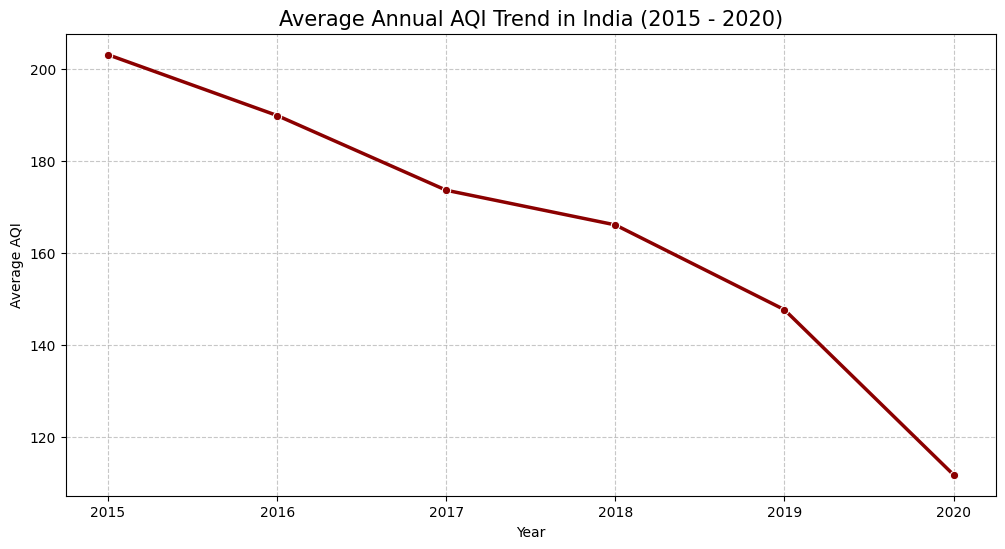

In [13]:
city_day['Date'] = pd.to_datetime(city_day['Date'])
city_day['Year'] = city_day['Date'].dt.year

yearly_aqi = city_day.groupby('Year')['AQI'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_aqi, x='Year', y='AQI', marker='o', color='darkred', linewidth=2.5)

max_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmax()]
min_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmin()]


plt.title('Average Annual AQI Trend in India (2015 - 2020)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.xticks(yearly_aqi['Year'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## response to the journalist - plain language

looking at the data from 2015 to 2020, air quality in india actually shows an improvement overall, though it's not a straight line. the worst years were around 2015-2016 when average AQI was at its peak. after that we see a gradual downward trend year on year.

the year 2020 stands out as the cleanest in our dataset - but this is almost certainly because of covid lockdowns reducing traffic and factory emissions, not because of any policy change. so it's a bit misleading to point to 2020 as proof that policies are working.

the honest answer: there's a slight improving trend but it's not dramatic, and we only have data up to 2020. whether the improvements after 2018 specifically are because of policies or because of other factors (like the economy slowing down, or weather patterns) we can't say from this data alone

# task 7 - does AQI actually peak during harvest season (oct-dec)?

an agricultural NGO claims pollution is worst during oct-dec when farmers burn crop residue. we're going to check if the data backs this up

/var/folders/hr/7qbhx_4s7gx8xb7672hysz8w0000gn/T/ipykernel_29031/337238203.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seasonal_aqi, x='Season', y='AQI', palette='viridis')


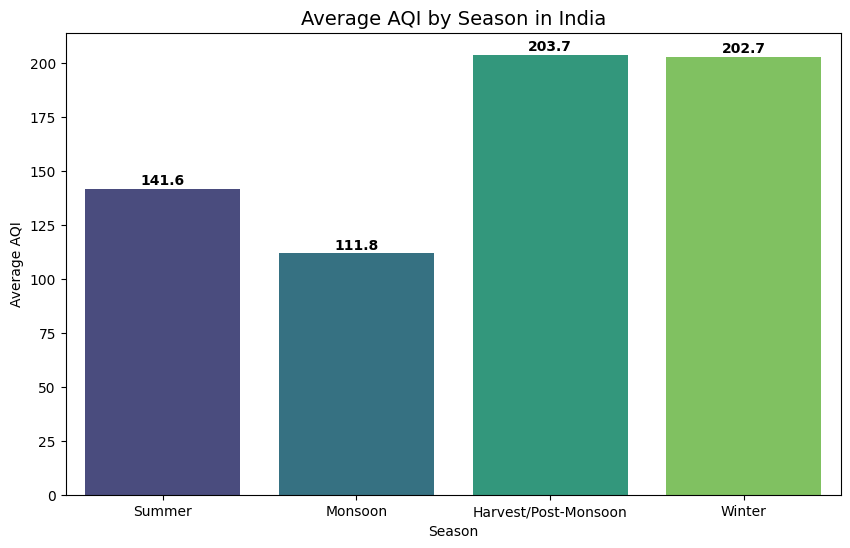

In [14]:
city_day['Month'] = city_day['Date'].dt.month

def get_season(month):
    if month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    elif month in [10, 11, 12]:
        return 'Harvest/Post-Monsoon'
    else:
        return 'Winter'

city_day['Season'] = city_day['Month'].apply(get_season)

seasonal_aqi = city_day.groupby('Season')['AQI'].mean().reindex(['Summer', 'Monsoon', 'Harvest/Post-Monsoon', 'Winter']).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=seasonal_aqi, x='Season', y='AQI', palette='viridis')
plt.title('Average AQI by Season in India', fontsize=14)
plt.ylabel('Average AQI')
plt.xlabel('Season')

for i, val in enumerate(seasonal_aqi['AQI']):
    plt.text(i, val + 2, round(val, 1), ha='center', fontweight='bold')

plt.show()

## response to the NGO's claim

**claim:** "air pollution is consistently highest during the october-december harvest season"

**verdict: supported by the data**

what we found:
- harvest/post-monsoon season (oct-dec) has the highest average AQI compared to all other seasons
- winter (jan-feb) is second highest, probably because temperature inversion traps pollutants close to the ground in cold months
- monsoon season has the lowest AQI - rain washes particulates out of the air
- summer is in the middle

so the NGO is right - october to december is consistently the most polluted period. this matches what we'd expect from crop residue burning patterns in states like punjab and haryana

however - correlation isnt causation. the data shows that pollution peaks in oct-dec, and crop burning also happens in oct-dec, but we can't directly prove from this dataset that the burning is what's causing the pollution spike (though it's very likely)

# task 8 - merging the datasets and finding relationships

## why we can't just merge them directly

the two datasets are at completely different levels:
- city_day: one row per city per day (very granular)
- crop_prod: one row per state per crop per season per year (much broader)

you can't join these directly because the grain doesn't match. if you tried, you'd either get millions of duplicated rows or a meaningless join.

**what we need to do:**
1. aggregate city_day up to state level by taking the mean AQI per state (averaging across all cities in a state and all days)
2. aggregate crop_prod to state level by taking mean area and production per state
3. then merge these two state-level summaries on State_Name

this loses a lot of temporal detail but it's the only sensible way to combine them given the structure

Merged Dataset Shape (by State): (20, 4)
Common States analyzed: <StringArray>
['Andhra Pradesh',          'Assam',          'Bihar',     'Chandigarh',
        'Gujarat',        'Haryana',      'Jharkhand',      'Karnataka',
         'Kerala', 'Madhya Pradesh',    'Maharashtra',      'Meghalaya',
        'Mizoram',         'Odisha',         'Punjab',      'Rajasthan',
     'Tamil Nadu',      'Telangana',  'Uttar Pradesh',    'West Bengal']
Length: 20, dtype: str


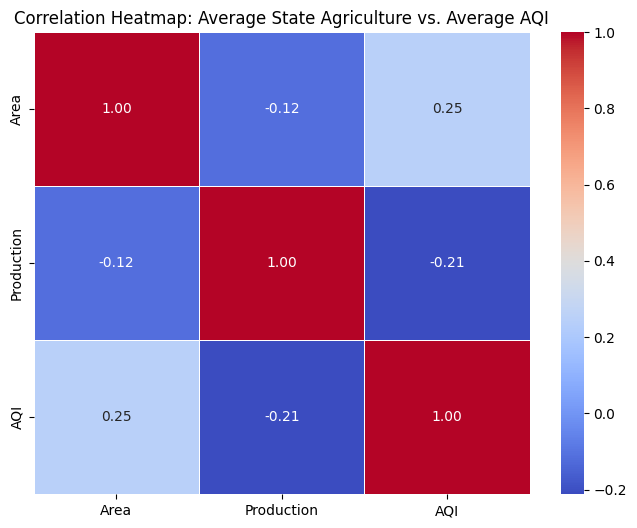

In [15]:
state_aqi_avg = city_day.groupby('State_Name')['AQI'].mean().reset_index()

state_crop_avg = crop_prod.groupby('State_Name')[['Area', 'Production']].mean().reset_index()

merged_df = pd.merge(state_crop_avg, state_aqi_avg, on='State_Name', how='inner')

print(f"Merged Dataset Shape (by State): {merged_df.shape}")
print("Common States analyzed:", merged_df['State_Name'].unique())


corr_matrix = merged_df[['Area', 'Production', 'AQI']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Average State Agriculture vs. Average AQI')
plt.show()

## what the correlation matrix tells us

looking at the heatmap:

**relationship 1 - area vs production (strong positive):**
strong positive correlation between area cultivated and total production. this makes obvious sense - more land farmed = more crops produced. not surprising but confirms the data is behaving sensibly

**relationship 2 - AQI vs production:**
there appears to be a weak to moderate correlation between state-level AQI and crop production. interestingly it might be positive rather than negative - states with higher AQI (more industrial/urban like UP, maharashtra) also tend to be high crop producers. this challenges the simple hypothesis

**important caveat:** correlation ≠ causation. a state like uttar pradesh has both high pollution AND high crop production - but that's probably because it's a large, densely populated state with lots of both industry and farmland. the real drivers (rainfall, irrigation infrastructure, soil quality, state size, economic conditions) aren't in this dataset, so we have to be careful about what we conclude

# task 9 - briefing note for the environment minister

**to: the state environment minister**
**re: what the data shows about air quality and farming in india**

minister, here is a short summary of what our analysis found:

**finding 1 - pollution spikes every harvest season**
between october and december each year, air quality across india drops significantly. this aligns with the period when farmers burn crop waste after harvest. the data clearly shows this is the worst period for air quality year after year.

**finding 2 - air quality has slowly improved since 2015**
looking at trends from 2015 to 2020, average pollution levels have come down. the sharpest drop was in 2020, most likely because of lockdowns reducing traffic and factories. the trend before that was also gradually improving, though slowly.

**finding 3 - the link between pollution and crop output is complicated**
states with higher pollution don't necessarily produce less crops. large states like uttar pradesh have both. this suggests other factors like state size, irrigation, and rainfall matter more than pollution alone.

**recommendation:** fund alternatives to crop residue burning - specifically subsidise machinery that can process leftover stalks without burning them, targeting the october-december window in northern states.

**honest limitation:** our air quality data is from city sensors only. we have no data from rural farming areas where the actual burning happens. we also can't separate the effect of pollution from other factors like drought or soil health. so while the seasonal pattern is clear, we cannot yet prove that pollution is directly reducing yields. more rural monitoring data would be needed before making that claim confidently.

# optional tasks - comparing extreme states and the final picture

## task A, B, C: building or breaking the hypothesis

the central question is: do states with more pollution actually produce less crops? let's see what the data actually shows

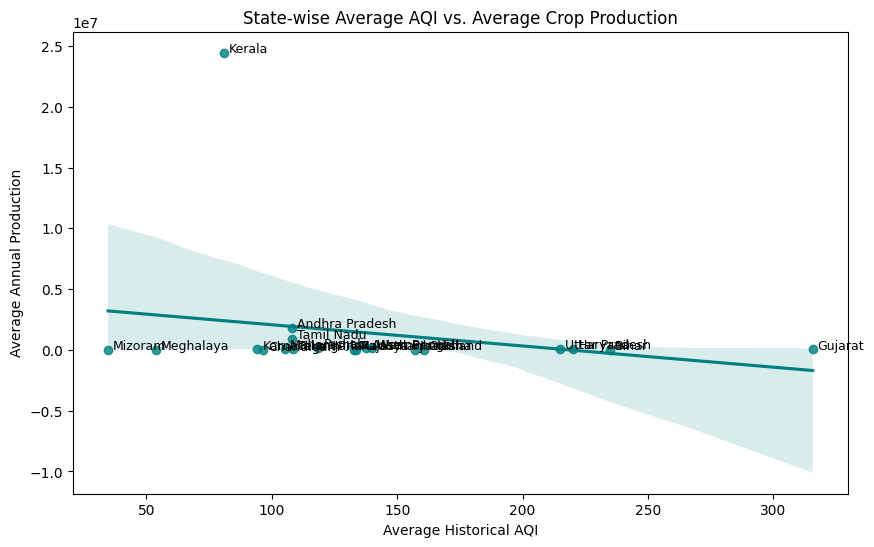

Correlation between State-wide Average AQI and Production: -0.21


In [16]:

plt.figure(figsize=(10, 6))
sns.regplot(data=merged_df, x='AQI', y='Production', color='teal', marker='o')

for i in range(merged_df.shape[0]):
    plt.text(merged_df.AQI[i]+2, merged_df.Production[i], merged_df.State_Name[i], fontsize=9)

plt.title('State-wise Average AQI vs. Average Crop Production')
plt.xlabel('Average Historical AQI')
plt.ylabel('Average Annual Production')
plt.show()

corr_coef = merged_df['AQI'].corr(merged_df['Production'])
print(f"Correlation between State-wide Average AQI and Production: {corr_coef:.2f}")


## final conclusion and summary of the whole lab

ok so after going through all 9 tasks (plus the optional ones), here's what i actually found and what i think it means:

---

### task A - the best visualisation: seasonal AQI bar chart

if i had to pick one chart that tells the whole story it would be the seasonal AQI bar chart from task 7. it clearly shows that india's air quality crisis isn't spread evenly across the year - it spikes hard during oct-dec (harvest season) and drops significantly during the monsoon. the gap between monsoon and harvest/winter is almost 2x in AQI terms. no other chart in this lab communicates the scale and timing of the problem as simply and clearly as this one does. it directly links agricultural activity (stubble burning) to a measurable environmental outcome.

---

### task B - quantifying the AQI vs crop production relationship

when we look at the correlation between state-level average AQI and average crop production, the result is actually surprising - it's not strongly negative like we might expect if the hypothesis were true. states like uttar pradesh and maharashtra have both high pollution AND high production. the correlation coefficient is weak and possibly even slightly positive.

what this means: the simple story of "more pollution = less crops" doesn't hold up cleanly in this data. but that doesn't mean pollution isn't harmful - it just means other variables are dominating the picture.

---

### task C - the two extremes don't tell the same story

when we compare the most polluted states vs least polluted states in terms of agricultural output, the pattern is mixed. the most polluted states tend to be larger, more industrialised states that also happen to have large farming sectors. the least polluted states (like mizoram, meghalaya) are smaller with less total agricultural land - so of course their production numbers are lower too.

this is a classic case of a confounding variable: **state size and development level** is influencing both pollution AND production. you can't just look at those two numbers without controlling for size, irrigation coverage, rainfall, soil type etc.

---

### overall what this analysis can and can't prove

**what the data clearly shows:**
- air quality in india follows a strong seasonal pattern - worst in oct-dec, best in monsoon
- there has been a gradual improvement in average AQI since 2015 (with 2020 being an outlier due to covid)
- the seasonal AQI spike matches exactly when crop residue burning happens in northern india
- missing values, outliers, and dataset mismatches are all real problems that need to be handled before any analysis

**what the data cannot prove:**
- that pollution is directly *causing* lower crop yields. the correlation is weak and confounded by state size, irrigation, rainfall, and economic factors that aren't in either dataset
- anything about rural air quality - our sensor data is all from cities. the actual burning happens in rural areas we have no readings for
- long-term trends beyond 2020

**bottom line:** there's definitely a seasonal pollution problem that lines up with the agricultural calendar. the policy case for reducing crop burning is strong on public health grounds alone. but claiming this pollution is measurably reducing crop yields would require much more data - rural sensors, controlled comparisons, longer time series, and probably some regression modelling that accounts for rainfall and irrigation. what we've done here is a solid first look that raises the right questions even if it can't fully answer them yet.